### First we generate language n-grams

In [23]:
from pathlib import Path
from collections import Counter

import pandas as pd
from nltk.util import ngrams

In [24]:
def generate_character_ngrams(text, n=3):
    text = "_".join(text.lower().split())

    return Counter(
        ''.join(g)
        for g in ngrams(text, n)
    )

In [27]:
OUTPUT_DIR = Path("../data/ngrams")
OUTPUT_DIR.mkdir(exist_ok=True)

for language, text in corpora.items():
    counts = generate_character_ngrams(text, 3)

    df = (
        pd.DataFrame(
            counts.items(),
            columns=["ngram", "frequency"]
        )
        .sort_values("frequency", ascending=False)
        .reset_index(drop=True)
    )

    df.to_csv(
        OUTPUT_DIR / f"{language}_character_trigrams.csv",
        index=False
    )

    print(f"Saved {language}")

Saved Bikol
Saved Cebuano
Saved English
Saved Hiligaynon
Saved Ilocano
Saved Kapampangan
Saved Pangasinense
Saved Spanish
Saved Tagalog
Saved Waray


### Determining how many trigrams are taken into account

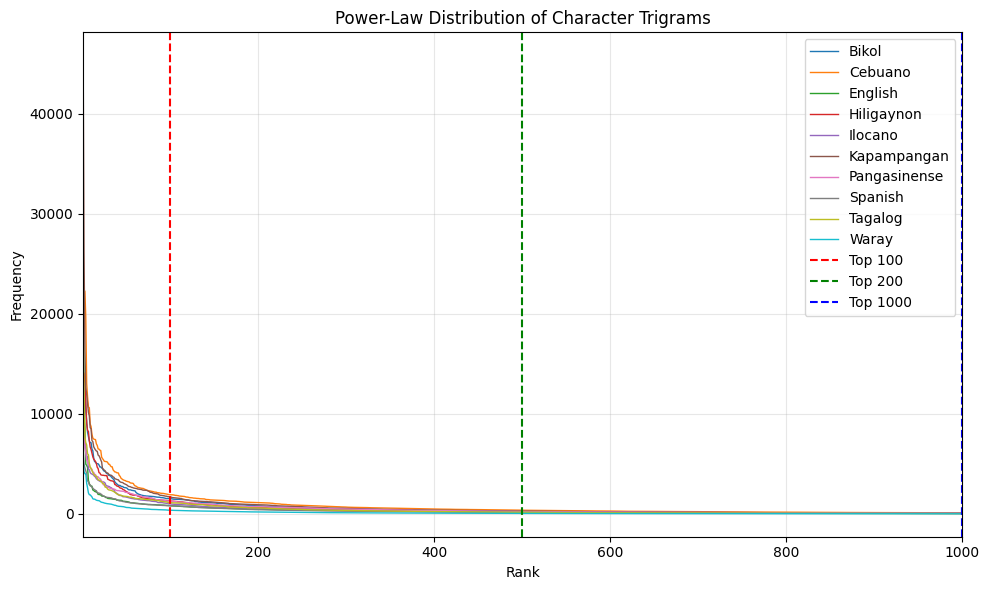

In [39]:
import matplotlib.pyplot as plt

MAX_RANK = 1000

plt.figure(figsize=(10, 6))

for language, text in corpora.items():
    counts = generate_character_ngrams(text, 3)

    frequencies = sorted(counts.values(), reverse=True)[:MAX_RANK]

    plt.plot(
        range(1, len(frequencies) + 1),
        frequencies,
        linewidth=1,
        label=language
    )

plt.axvline(100, color='red', linestyle='--', label='Top 100')
plt.axvline(500, color='green', linestyle='--', label='Top 200')
plt.axvline(1000, color='blue', linestyle='--', label='Top 1000')

plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Power-Law Distribution of Character Trigrams")
plt.xlim(1, MAX_RANK)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

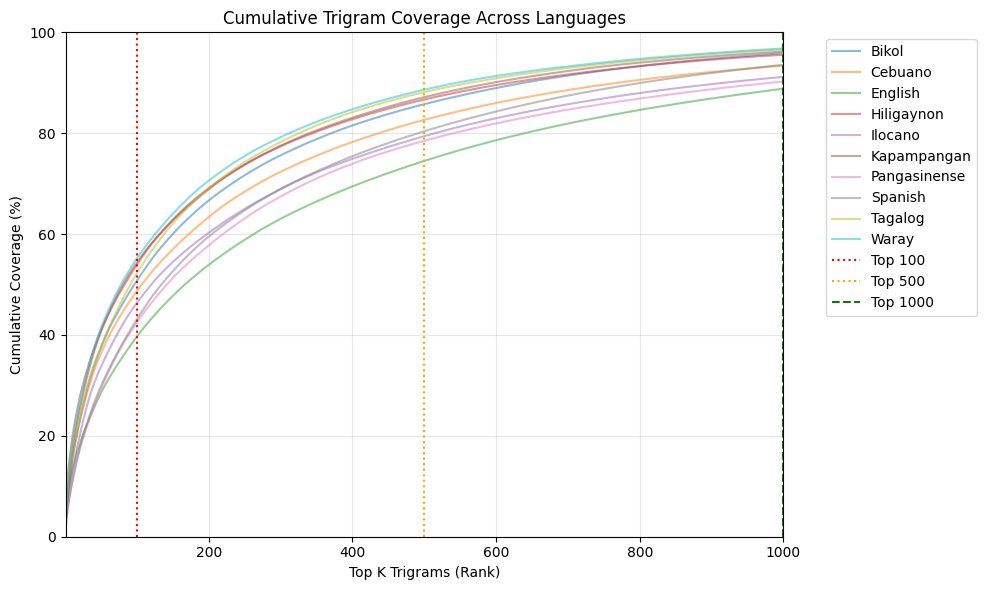

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for language, text in corpora.items():
    counts = generate_character_ngrams(text, 3)
    freqs = sorted(counts.values(), reverse=True)
    total = sum(freqs)
    
    # Calculate cumulative coverage percentage
    cum_coverage = [sum(freqs[:k]) / total * 100 for k in range(1, min(len(freqs), 1000) + 1)]
    
    plt.plot(range(1, len(cum_coverage) + 1), cum_coverage, alpha=0.5, label=language)

# Cutoff Milestones
plt.axvline(100, color='red', linestyle=':', label='Top 100')
plt.axvline(500, color='orange', linestyle=':', label='Top 500')
plt.axvline(1000, color='green', linestyle='--', label='Top 1000')

plt.xlabel("Top K Trigrams (Rank)")
plt.ylabel("Cumulative Coverage (%)")
plt.title("Cumulative Trigram Coverage Across Languages")
plt.xlim(1, 1000)
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [35]:
coverage = []

for language, text in corpora.items():
    counts = generate_character_ngrams(text, 3)

    freqs = sorted(counts.values(), reverse=True)
    total = sum(freqs)

    for k in [50, 100, 200, 500, 1000]:
        top = sum(freqs[:k])
        coverage.append({
            "Language": language,
            "Top K": k,
            "Coverage (%)": top / total * 100
        })

coverage_df = pd.DataFrame(coverage)

coverage_df.groupby("Top K")["Coverage (%)"].agg(
    ["mean", "std", "min", "max"]
).round(2)

,mean,std,min,max
Top K,,,,
50,35.54,4.98,28.47,41.33
100,48.66,5.53,39.67,55.20
200,63.89,5.78,53.89,70.59
500,83.18,4.81,74.50,88.62
1000,93.82,2.87,88.82,96.80
